# OPENING NOTES
The core focus of this experimentation notebook is improving the generalisation of the RAF-DB images. The key problems I noticed with my previous implementation were:
- RAF-DB and FER2013's test sets were using the same data augmentations. This is troublesome as RAF-DB is another in-the-wild dataset with its own resolution and dataset-independent format. I need to analyse why exactly the translation to this unseen dataset is especially difficult
- Uncertainty is not being quantified, which is needed in foreign data.
- Timm's `SwinTransformerBlock` is currently a black box to me, although I am evidently replacing the only part of it that allows for Swin-Xception to take effect (replacing the MLP head with a DS-FFN). I will take this notebook to identify if any further components could use adjustments befitting of my experiment

# KEY CHANGES
- Examine key errors when classifying RAF-DB [x]
- Predict with uncertainty estimation using MCDO [x]
- Swin-Tiny's Embedding and head count [x]

# New Changes 05/02/2026
- Adding Maximum Mean Discrepancy for RAF-DB Domain Adaptation [x]
- Add buffs to Swin-Tiny: [x]
  - Increase embeddings to 128
  - Third layer has 8 blocks instead of 6
- Add Knowledge Distillation and ResNet-50 teacher [x]

# 0. Import all core dependencies

In [2]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import timm
from timm.models.swin_transformer import SwinTransformerBlock

# Optimisers and Schedulers
from torch.optim import AdamW, RMSprop, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, StepLR

# Data Handling
from PIL import Image
import numpy as np
import pandas as pd
import cv2

# Data Visualisation - TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Class Imbalance Handling - TODO
from imblearn.over_sampling import SMOTE
from collections import Counter

# Evaluation - TODO
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score
)

# Explainability - TODO
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Utilities
from tqdm import tqdm
from einops import rearrange
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
import random
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Configure PyTorch to use my GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


# 1. Define all modules in Swin-Xception

## 1.1 Patch Embedding Block

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                 in_channels:int=3,
                 dim:int=128,
                 patch_size:int=4):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size
        self.dim = dim

        self.patcher = nn.Conv2d(in_channels=in_channels, out_channels=dim, kernel_size=patch_size, stride=patch_size, padding=0)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):

        image_resolution = x.shape[-1]

        assert image_resolution % self.patch_size == 0, \
            f"Input image size must be divisible by patch size, \
            image shape: {image_resolution}, patch size: {self.patch_size}"
        
        x_patched = self.patcher(x)

        x_flattened = self.flatten(x_patched)

        x = x_flattened.permute(0,2,1)

        x = self.norm(x)

        return x

## 1.2 Patch Merging Block

In [4]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super(PatchMerging, self).__init__()

        self.dim = dim

        self.reduction = nn.Linear(4*dim, 2*dim, bias=False)

        self.norm = nn.LayerNorm(4*dim)

    def forward(self, x):

        B, N, C = x.shape

        H = W = int(np.sqrt(N))

        assert H % 2 == 0 and W % 2 == 0, f"H and W must be even, got H={H}, W={W}"

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat([x0,x1,x2,x3], dim=-1)

        x = x.view(B, -1, 4*C)

        x = self.norm(x)

        x = self.reduction(x)

        return x

## 1.3 Depthwise Separable Convolution (The Xception side)

In [5]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size:int=3):
        super(DepthwiseSeparableConv, self).__init__()

        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, padding=kernel_size//2, groups=in_channels)
        
        self.gelu = nn.GELU()

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):

        x = self.depthwise(x)

        x = self.gelu(x)

        x = self.pointwise(x)

        return x
    

## 1.4 Depthwise Separable FFN (Replaces MLP Head of Swin Block)

In [6]:
class DepthwiseSeparableFFN(nn.Module):
    def __init__(self,
                 dim,
                 mlp_ratio:int=8,
                 dropout:float=0.5):
        super(DepthwiseSeparableFFN, self).__init__()

        hidden_dim = int(dim * mlp_ratio)

        self.depthwise1 = DepthwiseSeparableConv(dim, hidden_dim, kernel_size=3)

        self.dropout1 = nn.Dropout(dropout)

        self.depthwise2 = DepthwiseSeparableConv(hidden_dim, dim, kernel_size=3)

        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):

        B, N, C = x.shape

        H = W = int(np.sqrt(N))

        x = x.transpose(1, 2).reshape(B, C, H, W)

        x = self.depthwise1(x)

        x = self.dropout1(x)

        x = self.depthwise2(x)

        x = self.dropout2(x)

        x = x.reshape(B, C, N).transpose(1, 2)

        return x

## 1.5 Swin-Xception Block

In [7]:
class SwinXceptionBlock(nn.Module):
    """Swin Transformer block that uses depthwise separable FFN instead of an MLP"""
    def __init__(self,
                 embedding_dim,
                 num_heads,
                 input_resolution,
                 window_size:int=7,
                 shift_size:int=0,
                 mlp_ratio:int=8):
        super(SwinXceptionBlock, self).__init__()

        from timm.models.swin_transformer import SwinTransformerBlock

        self.block = SwinTransformerBlock( # Use timm's Swin Transformer Block...
            dim=embedding_dim,
            input_resolution=input_resolution,
            num_heads=num_heads,
            window_size=window_size,
            shift_size=shift_size,
            mlp_ratio=mlp_ratio,
            proj_drop=0.2,
            attn_drop=0.2,
            drop_path=0.2
        )

        self.input_resolution = input_resolution

        self.block.mlp = DepthwiseSeparableFFN(embedding_dim, mlp_ratio) # But replace the mlp head with my DS-FFN

    def forward(self, x): # X input is sequential transformer data
        B, N, C = x.shape

        H, W = self.input_resolution # height and width

        x = x.view(B, H, W, C)

        # Swin blocks accept inputs as spatial grid
        x = self.block(x)

        # back to sequential data
        x = x.view(B, N, C)
        
        return x

## 1.6 Swin-Xception Backbone

In [8]:
class SwinXception(nn.Module):
    def __init__(self, num_classes:int=7, dropout:float=0.3):
        super(SwinXception, self).__init__()

        self.patch_embed = PatchEmbedding(in_channels=3, dim=128, patch_size=4)

        self.layer1 = nn.ModuleList([SwinXceptionBlock(128, num_heads=4, input_resolution=(56, 56), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])
        self.merge1 = PatchMerging(128) # Reduce dimensions, increase channels

        self.layer2 = nn.ModuleList([SwinXceptionBlock(256, num_heads=8, input_resolution=(28, 28), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])
        self.merge2 = PatchMerging(256)

        self.layer3 = nn.ModuleList([SwinXceptionBlock(512, num_heads=16, input_resolution=(14, 14), shift_size=0 if i % 2 == 0 else 3) for i in range(8)])
        self.merge3 = PatchMerging(512)

        self.layer4 = nn.ModuleList([SwinXceptionBlock(1024, num_heads=32, input_resolution=(7, 7), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])

        self.norm = nn.LayerNorm(1024)
        
        self.avgpool1d = nn.AdaptiveAvgPool1d(output_size=1)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):

        x = self.patch_embed(x)

        for block in self.layer1:
            x = block(x)
        x = self.merge1(x)

        for block in self.layer2:
            x = block(x)
        x = self.merge2(x)

        for block in self.layer3:
            x = block(x)
        x = self.merge3(x)

        for block in self.layer4:
            x = block(x)

        x = self.norm(x)
        x = x.transpose(1, 2)
        x = self.avgpool1d(x)
        x = torch.flatten(x, 1)
        x = self.head(x)

        return x

    def monte_carlo_dropout_predict(self, x, n_samples=10):
        self.train()
        predictions = []

        with torch.no_grad():
            for _ in range(n_samples):
                predictions.append(torch.softmax(self(x), dim=1))

        predictions = torch.stack(predictions)
        mean_pred = predictions.mean(dim=0)
        uncertainty = predictions.std(dim=0)

        return mean_pred, uncertainty

## 1.7 Knowledge Distillation Method: Distillation Loss

In [9]:
class DistillationLoss(nn.Module):
    def __init__(self, temperature=4.0, alpha=0.5):
        super(DistillationLoss, self).__init__()
        self.T = temperature
        self.alpha = alpha
        self.hard_loss = nn.CrossEntropyLoss()
        self.soft_loss = nn.KLDivLoss(reduction="batchmean")

    def forward(self, student_logits, teacher_logits, labels):
        # Standard "Hard" Loss (Student model vs Ground Truth)
        # Assume student_logits are raw scores (not softmaxed yet)
        hard_loss = self.hard_loss(student_logits, labels)

        # Distillation "Soft" Loss (Student model vs Teacher Model)
        # Soften probabilities by dividing by Temperature T
        soft_targets = F.softmax(teacher_logits / self.T, dim=1)
        soft_prob = F.log_softmax(student_logits / self.T, dim=1)

        # Calculate KL Divergence
        # We multiply by T^2 to scale gradients back up (standard KD trick)
        distillation_loss = self.soft_loss(soft_prob, soft_targets) * (self.T ** 2)

        # Combine Hard and Soft Loss
        total_loss = (self.alpha * hard_loss) + ((1 - self.alpha) * distillation_loss)
        return total_loss

# 2. Image Preprocessing function

In [10]:
NOTEBOOK_DIR = os.getcwd()

SRC_PATH = os.path.abspath("../../src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from datasets import FERDataset
from torchvision.transforms import v2

transform_train = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    
    # 1. RandomResizedCrop: The single best augmentation. 
    # Forces model to classify "Sad" from just an eye or a mouth.
    v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), interpolation=v2.InterpolationMode.BICUBIC, antialias=True),
    
    # 2. RandomRotation: Faces aren't always perfect vertical
    v2.RandomRotation(degrees=10),
    
    # 3. ColorJitter: Changes brightness/contrast so lighting doesn't matter
    # v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    
    v2.RandomHorizontalFlip(p=0.5),
    
    # 4. RandomErasing: Randomly blocks out parts of the face
    # Forces model to look at the WHOLE face, not just one feature.
    # v2.RandomErasing(p=0.1),
    
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), interpolation=v2.InterpolationMode.BICUBIC, antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

fer_train = FERDataset(os.path.abspath("../../datasets/FER2013/train"), transform_train)
fer_test = FERDataset(os.path.abspath("../../datasets/FER2013/test"), transform_test)
raf_test = FERDataset(os.path.abspath("../../datasets/RAFDB/DATASET/test"), transform_test)

train_loader = DataLoader(fer_train, batch_size=32, shuffle=True, num_workers=4)
test_fer_loader = DataLoader(fer_test, batch_size=32, shuffle=False, num_workers=4)
test_raf_loader = DataLoader(raf_test, batch_size=32,shuffle=False, num_workers=4)

print(f"FER2013 Training set images: {len(fer_train)}")
print(f"FER2013 Test set images: {len(fer_test)}")
print(f"RAF-DB Test set images: {len(raf_test)}")

FER2013 Training set images: 28709
FER2013 Test set images: 7178
RAF-DB Test set images: 3068


# 3. Stage 1: End-to-End Student Training

## 3.1 Train Functions

### 3.1.1 Baseline Train Function

In [25]:
def distillation_loss(student_logits, teacher_logits, labels, T=3.0, alpha=0.5):
    # Standard Cross Entropy Loss ("Hard" Target)
    hard_loss = F.cross_entropy(student_logits, labels)

    # KL Divergence Loss (The "Soft" Target from the Teacher)
    # Apply LogSoftmax to the student, and Softmax to the teacher
    soft_student = F.log_softmax(student_logits / T, dim=1)
    soft_teacher = F.softmax(teacher_logits / T, dim=1)

    # reduction='batchmean' is mathematically correct for KL Divergence
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean')

    #Scale the softloss by T^2 to match the scale of the hard loss
    soft_loss = soft_loss * (T ** 2)

    return (alpha * soft_loss) + ((1.0 - alpha) * hard_loss)

In [32]:
def train_one_epoch_kd(student_model, teacher_model, data_loader, criterion, optimiser, device, T=3.0, alpha=0.5):
    student_model.train()
    teacher_model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(data_loader, desc="Distilling"):
        images = images.to(device)
        labels = labels.to(device)

        # Teacher Predictions, Frozen grad
        with torch.no_grad():
            teacher_logits = teacher_model(images)

        student_logits = student_model(images)

        loss = distillation_loss(student_logits, teacher_logits, labels, T=T, alpha=alpha)

        # Backpropagation
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = correct * 100. / total
    return epoch_loss, epoch_acc

### 3.1.2 Train Function with MMD

In [27]:
def mmd_loss (source_features, target_features, kernel='rbf'):
    """
    Maximum Mean Discrepancy loss
    Measures distribution distance between source and target features
    """
    def gaussian_kernel(x, y, sigma=1.0):
        dist = torch.cdist(x, y, p=2)
        return torch.exp(-dist**2 / (2* sigma**2))

    K_ss = gaussian_kernel(source_features, source_features).mean()
    K_tt = gaussian_kernel(target_features, target_features).mean()
    K_st = gaussian_kernel(source_features, target_features).mean()

    return K_ss + K_tt - 2 * K_st


def extract_features_single_batch(model, images):
    """Extract features from a single batch (for domain adaptation)"""
    x = model.patch_embed(images)

    for block in model.layer1:
        x = block(x)
    x = model.merge1(x)
    
    for block in model.layer2:
        x = block(x)
    x = model.merge2(x)
    
    for block in model.layer3:
        x = block(x)
    x = model.merge3(x)
    
    for block in model.layer4:
        x = block(x)

    x = model.norm(x)
    x = x.transpose(1, 2)
    x = model.avgpool1d(x)
    x = torch.flatten(x, 1)

    return x
    

def train_with_mmd(model, source_loader, target_loader, num_epochs=20, device='cuda', mmd_weight=0.1):
    """Train with MMD for domain adaptation"""
    optimiser = AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    criterion_cls = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        source_iter = iter(source_loader)
        target_iter = iter(target_loader)

        for _ in range(min(len(source_loader), len(target_loader))):
            # Get batches
            source_images, source_labels = next(source_iter)
            target_images, _ = next(target_iter)

            source_images = source_images.to(device)
            source_labels = source_labels.to(device)
            target_images = target_images.to(device)

            optimiser.zero_grad()

            # Extract features
            source_features = extract_features_single_batch(model, source_images)
            target_features = extract_features_single_batch(model, target_images)

            # Classification loss on source
            source_output = model.head(source_features)
            cls_loss = criterion_cls(source_output, source_labels)

            mmd = mmd_loss(source_features, target_features)

            total_loss = cls_loss + mmd_weight * mmd
            total_loss.backward()
            optimiser.step()

        print(f"Epoch {epoch+1}: Cls Loss={cls_loss.item():.4f}, MMD={mmd.item():.4f}")

## 3.2 Validation Function

In [28]:
def validate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(data_loader)
    val_acc = correct * 100. / total
    
    return val_loss, val_acc

## 3.3 ResNet50 Teacher Pre-Training

In [16]:
T_PATH = "model_checkpoints/teacher_resnet50.pth"
os.makedirs("model_checkpoints", exist_ok=True)

mixup = v2.MixUp(alpha=0.2, num_classes=7)
cutmix = v2.CutMix(alpha=1.0, num_classes=7)

cutmix_or_mixup = v2.RandomChoice([mixup, cutmix])

def train_teacher(model, train_loader, val_loader, epochs=60):
    best_acc = 0.0
    teacher_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Freeze backbone, train only head (Epochs 1-3)
    # This aligns the random head with the pre-trained body without wrecking the body
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters(): # ResNet's head is called 'fc'
        param.requires_grad = True
        
    print("Phase 1: Warming up head (3 Epochs)...")
    # Use Adam for quick head alignment
    warmup_optim = AdamW(model.fc.parameters(), lr=3e-3)
    
    for epoch in range(3):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Warmup {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            warmup_optim.zero_grad()
            loss = teacher_criterion(model(images), labels)
            loss.backward()
            warmup_optim.step()

    # Unfreeze and Train All (Epochs 4-30)
    print("Phase 2: Fine-tuning entire model...")
    for param in model.parameters():
        param.requires_grad = True
        
    teacher_optimiser = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    teacher_scheduler = CosineAnnealingLR(teacher_optimiser, T_max=epochs, eta_min=1e-6)

    for epoch in range(epochs):
        model.train()
        current_lr = teacher_optimiser.param_groups[0]['lr']
        running_loss = 0.0

        use_mixup = True if epoch < (epochs - 15) else False
        
        for images, labels in tqdm(train_loader, desc=f"Teacher Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)

            if use_mixup and torch.rand(1).item() < 0.5:
                images, labels = cutmix_or_mixup(images, labels)

            teacher_optimiser.zero_grad()
            loss = teacher_criterion(model(images), labels)
            loss.backward()
            teacher_optimiser.step()
            running_loss += loss.item()

        # Validation
        _, val_acc = validate(model, val_loader, nn.CrossEntropyLoss(), device)
        
        # Check LR change
        teacher_scheduler.step()
        current_lr = teacher_optimiser.param_groups[0]['lr']

        if (epoch % 5 == 0):
            print(f"Learning Rate: {current_lr}")

        print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), T_PATH)
            print(f"New Best Teacher Saved: ({best_acc:.2f}%)")

def get_model_with_dropout(model_name='resnet50', num_classes=7):
    model = timm.create_model(model_name, pretrained=True)
    
    n_inputs = model.fc.in_features
    
    model.fc = nn.Sequential(
        nn.Dropout(0.3),          
        nn.Linear(n_inputs, num_classes)
    )
    return model.to(device)

if not os.path.exists(T_PATH):
    print("Training Teacher: ResNet50 with Dropout...")
    temp_teacher = get_model_with_dropout()
    train_teacher(temp_teacher, train_loader, test_fer_loader)
else:
    print("Trained teacher model already acquired.")

Training Teacher: ResNet50 with Dropout...
Phase 1: Warming up head (3 Epochs)...


Warmup 3: 100%|██████████████████████████████████████████████████████████████████████| 898/898 [01:04<00:00, 13.89it/s]


Phase 2: Fine-tuning entire model...


100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:22<00:00, 10.20it/s]


Learning Rate: 9.99321619703514e-05
Epoch 1 | Loss: 1.6344 | Val Acc: 34.97%
New Best Teacher Saved: (34.97%)


...

Epoch 58 | Loss: 0.6243 | Val Acc: 49.01%


100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:21<00:00, 10.35it/s]


Epoch 59 | Loss: 0.6228 | Val Acc: 50.22%


100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:21<00:00, 10.38it/s]

Epoch 60 | Loss: 0.6247 | Val Acc: 50.15%


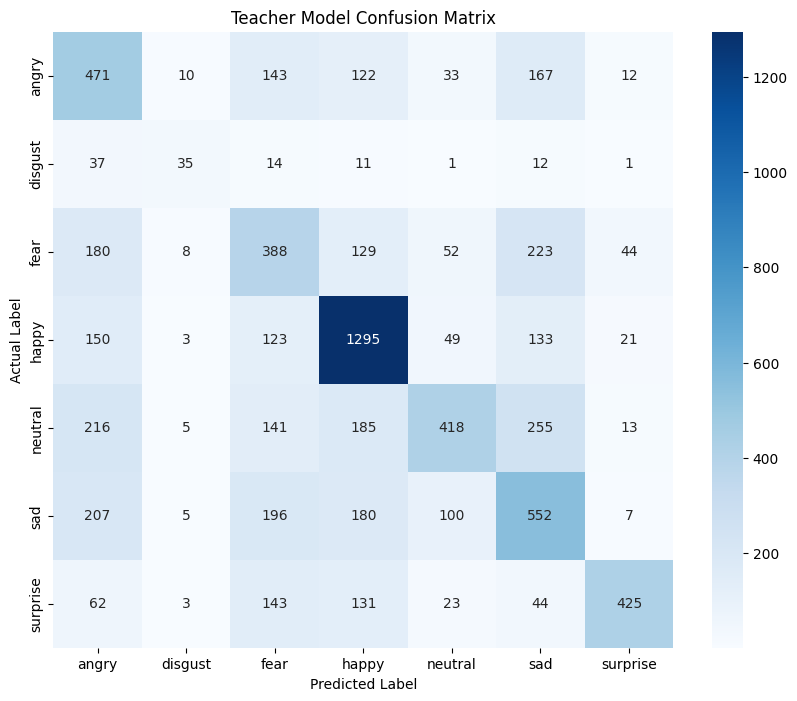

In [17]:
train_dataset = FERDataset(root_dir=os.path.abspath("../../datasets/FER2013/train"), transform=transform_train)
test_dataset = FERDataset(root_dir=os.path.abspath("../../datasets/FER2013/test"), transform=transform_test)

def plot_confusion_matrix(model, loader, dataset_object):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Calculate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=dataset_object.class_names, 
                yticklabels=dataset_object.class_names,
                cmap='Blues')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Teacher Model Confusion Matrix')
    plt.show()

# Run this call:
plot_confusion_matrix(temp_teacher, test_fer_loader, test_dataset)

## 3.4 Training and Validation from source domain

### 3.4.1 Set up my student (SwinXception) and teacher (ResNet-50)

In [29]:
def get_teacher_model(num_classes=7, device='cuda'):
    # Create Base Model
    teacher = timm.create_model('resnet50', pretrained=True, num_classes=num_classes)

    # Rebuild same head as temp teacher used (with the added dropout)
    n_inputs = teacher.fc.in_features
    teacher.fc = nn.Sequential(
        nn.Dropout(0.3), # fc.0
        nn.Linear(n_inputs, num_classes) # fc.1
    )
    
    teacher = teacher.to(device)

    if os.path.exists(T_PATH):
        teacher_checkpoint = torch.load(T_PATH, map_location=device)
        state_dict = teacher_checkpoint["model_state_dict"] if "model_state_dict" in teacher_checkpoint else teacher_checkpoint
        
        teacher.load_state_dict(state_dict)
        print("Successfully loaded teacher weights!")
    else:
        print("No trained teacher found, knowledge distillation will fail!")

    for param in teacher.parameters():
        param.requires_grad = False

    teacher.eval()
    return teacher

In [30]:
PATH = "model_checkpoints/latest.pth"
T_PATH = "model_checkpoints/teacher_resnet50.pth"
os.makedirs("model_checkpoints", exist_ok=True)

epochs = 50

# The student learning: SwinXception
student_model = SwinXception(num_classes=7).to(device)

# Teacher the student is learning from, pre-trained on FER
teacher_model = get_teacher_model(num_classes=7, device=device)

# alpha=0.5 means equal weight to ground truth and teacher
# temperature=4.0 is a good starting point for softening peaks
kd_criterion = DistillationLoss(temperature=4.0, alpha=0.5).to(device)

optimiser = AdamW(student_model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimiser, T_max=epochs)

start_epoch = 0

if os.path.exists(PATH):
    checkpoint = torch.load(PATH, map_location=device)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint found! Starting from epoch {start_epoch}...")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimiser_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
else:
    print("No student model checkpoints found. Starting from epoch 1...")

Successfully loaded teacher weights!
No student model checkpoints found. Starting from epoch 1...


In [33]:
T = 3.0     # Temperature: Higher = "softer" probabilities (usually 2.0 to 5.0)
alpha = 0.5 # Alpha: 0.5 means 50% teacher wisdom, 50% hard labels

for epoch in range(start_epoch, epochs):
    print("="*60)
    print(f"Epoch {epoch+1}/{epochs}")
    
    print("Training on FER2013...")
    train_loss, train_acc = train_one_epoch_kd(student_model, teacher_model, train_loader, kd_criterion, optimiser, device, T, alpha)

    print("Testing on FER2013...")
    fer_loss, fer_acc = validate(student_model, test_fer_loader, nn.CrossEntropyLoss(), device)

    print("Testing of RAF-DB...")
    raf_loss, raf_acc = validate(student_model, test_raf_loader, nn.CrossEntropyLoss(), device)
    
    scheduler.step()

    print(f"FER2013 Training | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"FER2013 Testing  | Loss: {fer_loss:.4f} | Accuracy: {fer_acc:.2f}%")
    print(f"RAF-DB Testing   | Loss: {raf_loss:.4f} | Accuracy: {raf_acc:.2f}%")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": student_model.state_dict(),
        "optimiser_state_dict": optimiser.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(checkpoint, PATH)
    
print("="*60)
torch.save(student_model.state_dict(), 'swin_xception_baseline.pth')

Epoch 1/50
Training on FER2013...


Distilling:   2%|█▏                                                                 | 16/898 [05:52<5:24:02, 22.04s/it]


KeyboardInterrupt: 

## 3.5 Domain Adaptation to RAF-DB

In [ ]:
target_loader = test_raf_loader

train_with_mmd(
    model,
    source_loader=train_loader,
    target_loader=target_loader,
    num_epochs=20,
    device=device,
    mmd_weight=0.1
)

torch.save(model.state_dict(), 'swin_xception_mmd_adapted.pth')

# 4. Evaluation and Metrics, Initial training

## 4.1 Confusion matrix

### 4.1.1 Run one evaluation to get all predictions

In [12]:
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Getting predictions"):
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

### 4.1.2 Plotting the confusion matrices

In [13]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize to percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'{title} - Raw Counts')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # Percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'{title} - Percentages (%)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    
    plt.show()

### 4.1.3 Detailed metrics

In [14]:
def print_detailed_metrics(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Per-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    
    print("\nPer-Class Accuracy:")
    for i, (class_name, acc) in enumerate(zip(class_names, per_class_acc)):
        print(f"{class_name:12s}: {acc:6.2f}%")
    
    # Overall accuracy
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"\nOverall Accuracy: {overall_acc:.2f}%")

### 4.1.4 Generate Matrices


Generating Confusion Matrices and Metrics

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:29<00:00,  7.65it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


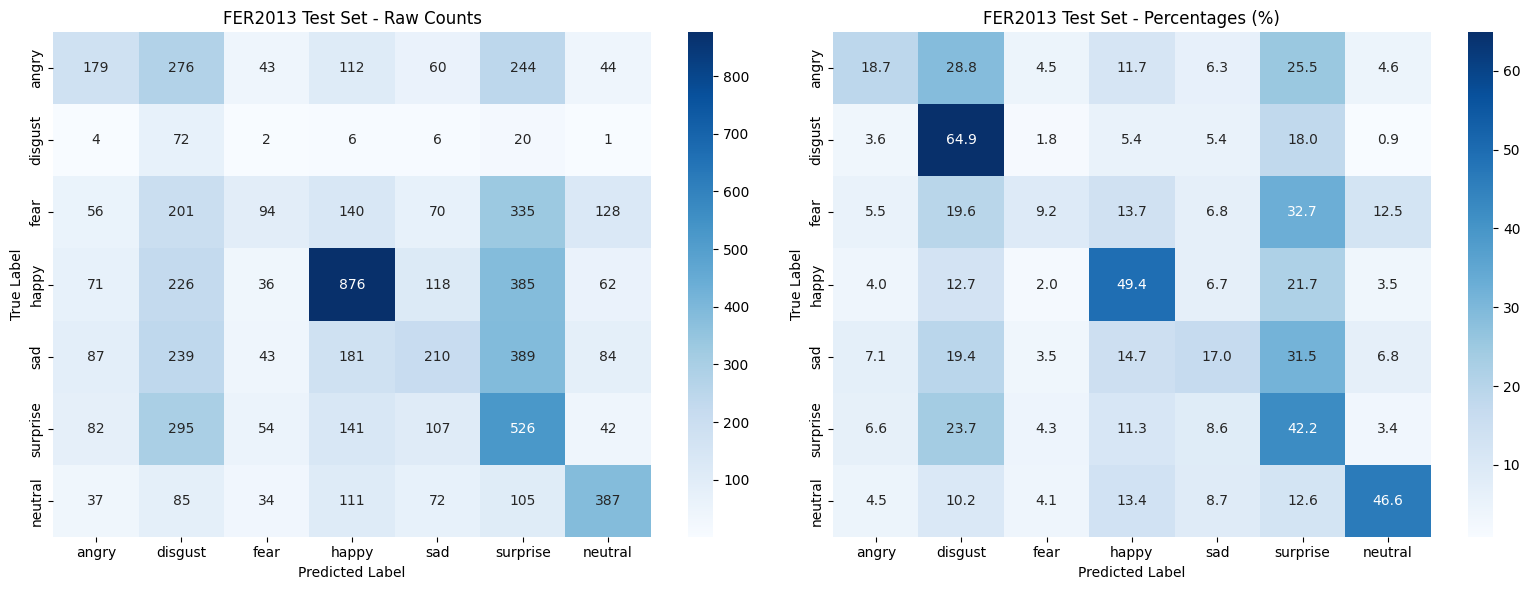


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.3469    0.1868    0.2429       958
     disgust     0.0516    0.6486    0.0957       111
        fear     0.3072    0.0918    0.1414      1024
       happy     0.5590    0.4938    0.5244      1774
         sad     0.3266    0.1703    0.2239      1233
    surprise     0.2625    0.4218    0.3236      1247
     neutral     0.5174    0.4657    0.4902       831

    accuracy                         0.3266      7178
   macro avg     0.3387    0.3541    0.2917      7178
weighted avg     0.3907    0.3266    0.3351      7178


Per-Class Accuracy:
angry       :  18.68%
disgust     :  64.86%
fear        :   9.18%
happy       :  49.38%
sad         :  17.03%
surprise    :  42.18%
neutral     :  46.57%

Overall Accuracy: 32.66%

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:15<00:00,  6.06it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


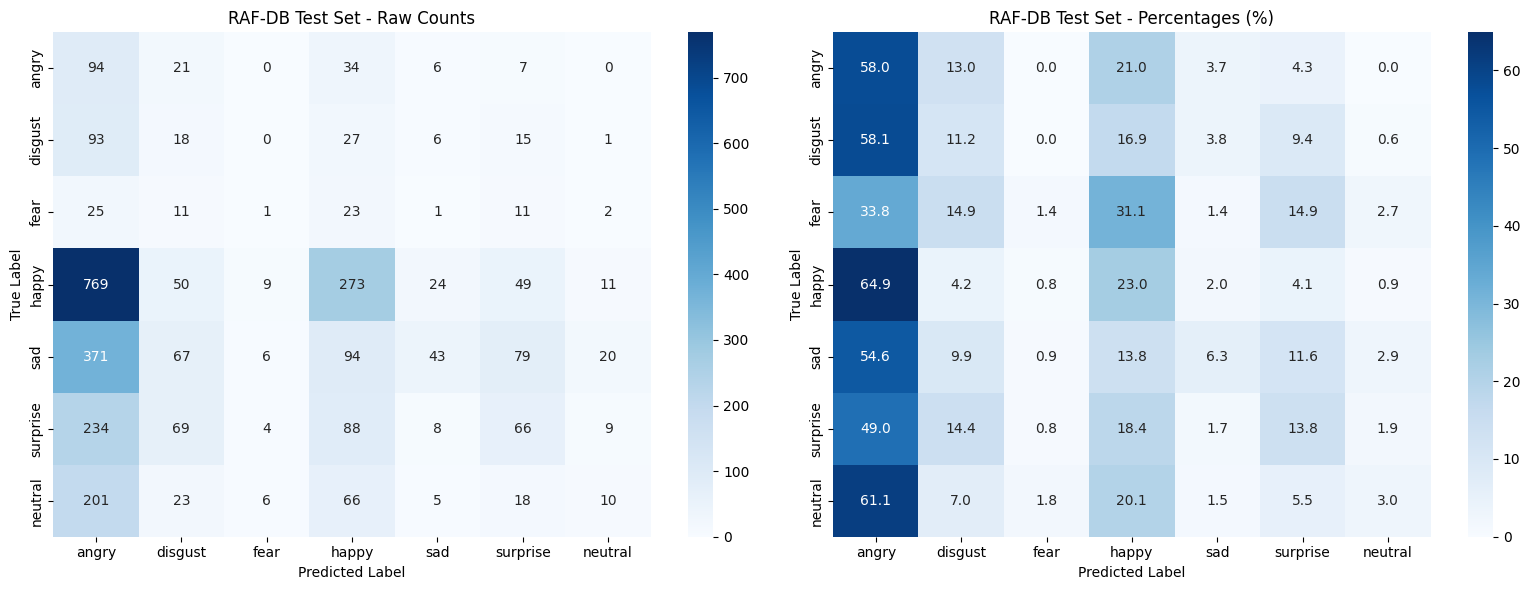


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.0526    0.5802    0.0965       162
     disgust     0.0695    0.1125    0.0859       160
        fear     0.0385    0.0135    0.0200        74
       happy     0.4512    0.2304    0.3050      1185
         sad     0.4624    0.0632    0.1113       680
    surprise     0.2694    0.1381    0.1826       478
     neutral     0.1887    0.0304    0.0524       329

    accuracy                         0.1646      3068
   macro avg     0.2189    0.1669    0.1219      3068
weighted avg     0.3463    0.1646    0.1866      3068


Per-Class Accuracy:
angry       :  58.02%
disgust     :  11.25%
fear        :   1.35%
happy       :  23.04%
sad         :   6.32%
surprise    :  13.81%
neutral     :   3.04%

Overall Accuracy: 16.46%


In [16]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics(fer_labels, fer_preds, emotions, 'FER2013')

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics(raf_labels, raf_preds, emotions, 'RAF-DB')

### 4.1.5 Compare Minority class performance

In [17]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    fer_mask = fer_labels == cls_idx
    raf_mask = raf_labels == cls_idx
    
    if fer_mask.sum() > 0:
        fer_acc = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize()} - FER2013: {fer_acc:.2f}% ({fer_mask.sum()} samples)")
    
    if raf_mask.sum() > 0:
        raf_acc = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize()} - RAF-DB:  {raf_acc:.2f}% ({raf_mask.sum()} samples)")
    print()


Minority Class Performance (Disgust & Fear)
Disgust - FER2013: 64.86% (111 samples)
Disgust - RAF-DB:  11.25% (160 samples)

Fear - FER2013: 9.18% (1024 samples)
Fear - RAF-DB:  1.35% (74 samples)



## 4.2 UAR and WAR

### 4.2.1 UAR and WAR calculation

In [20]:
def calculate_uar_war(y_true, y_pred, class_names):
    """
    Calculate UAR and WAR metrics
    
    UAR (Unweighted Average Recall): Mean of per-class recalls (treats all classes equally)
    WAR (Weighted Average Recall): Weighted mean of per-class recalls (weighted by class frequency)
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class recall (same as per-class accuracy for single-label classification)
    per_class_recall = cm.diagonal() / cm.sum(axis=1)
    
    # UAR: Simple average of all class recalls
    uar = np.mean(per_class_recall) * 100
    
    # WAR: Weighted average by class support
    class_support = cm.sum(axis=1)
    war = np.average(per_class_recall, weights=class_support) * 100
    
    return uar, war, per_class_recall

### 4.2.2 Detailed metrics with UAR and WAR

In [21]:
def print_detailed_metrics_with_uar_war(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics including UAR and WAR"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    
    # Standard classification report
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Calculate UAR and WAR
    uar, war, per_class_recall = calculate_uar_war(y_true, y_pred, class_names)
    
    print("\n" + "-"*60)
    print("Per-Class Recall (%):")
    print("-"*60)
    for class_name, recall in zip(class_names, per_class_recall):
        print(f"{class_name:12s}: {recall*100:6.2f}%")
    
    print("\n" + "-"*60)
    print("Summary Metrics:")
    print("-"*60)
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"Overall Accuracy: {overall_acc:.2f}%")
    print(f"WAR (Weighted Average Recall): {war:.2f}%")
    print(f"UAR (Unweighted Average Recall): {uar:.2f}%")
    print("-"*60)

### 4.2.3 Generate confusion matrices for test sets with UAR and WAR


Generating Confusion Matrices and Metrics

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:28<00:00,  7.92it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


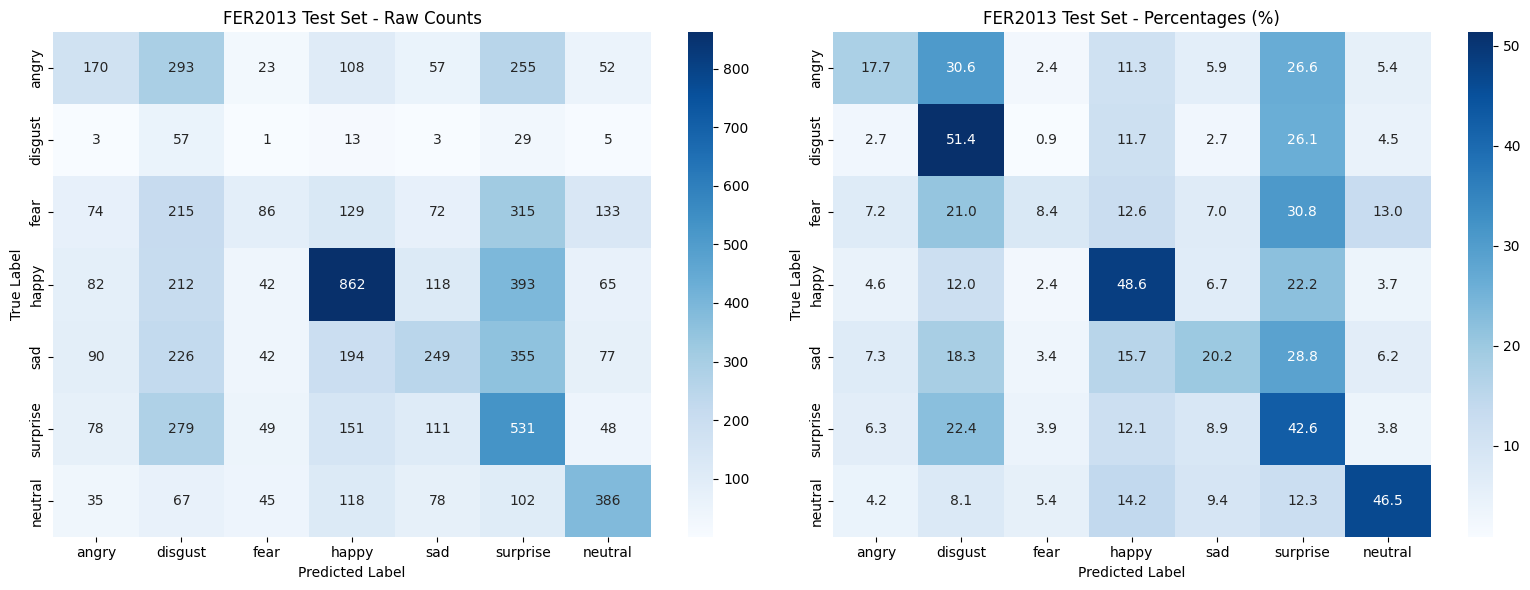


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.3195    0.1775    0.2282       958
     disgust     0.0423    0.5135    0.0781       111
        fear     0.2986    0.0840    0.1311      1024
       happy     0.5473    0.4859    0.5148      1774
         sad     0.3619    0.2019    0.2592      1233
    surprise     0.2682    0.4258    0.3291      1247
     neutral     0.5039    0.4645    0.4834       831

    accuracy                         0.3261      7178
   macro avg     0.3345    0.3362    0.2891      7178
weighted avg     0.3883    0.3261    0.3353      7178


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  17.75%
disgust     :  51.35%
fear        :   8.40%
happy       :  48.59%
sad         :  20.19%
surprise    :  42.58%
neutral     :  46.45%

------------------------------------------------------------
Summary Metric

Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:15<00:00,  6.03it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


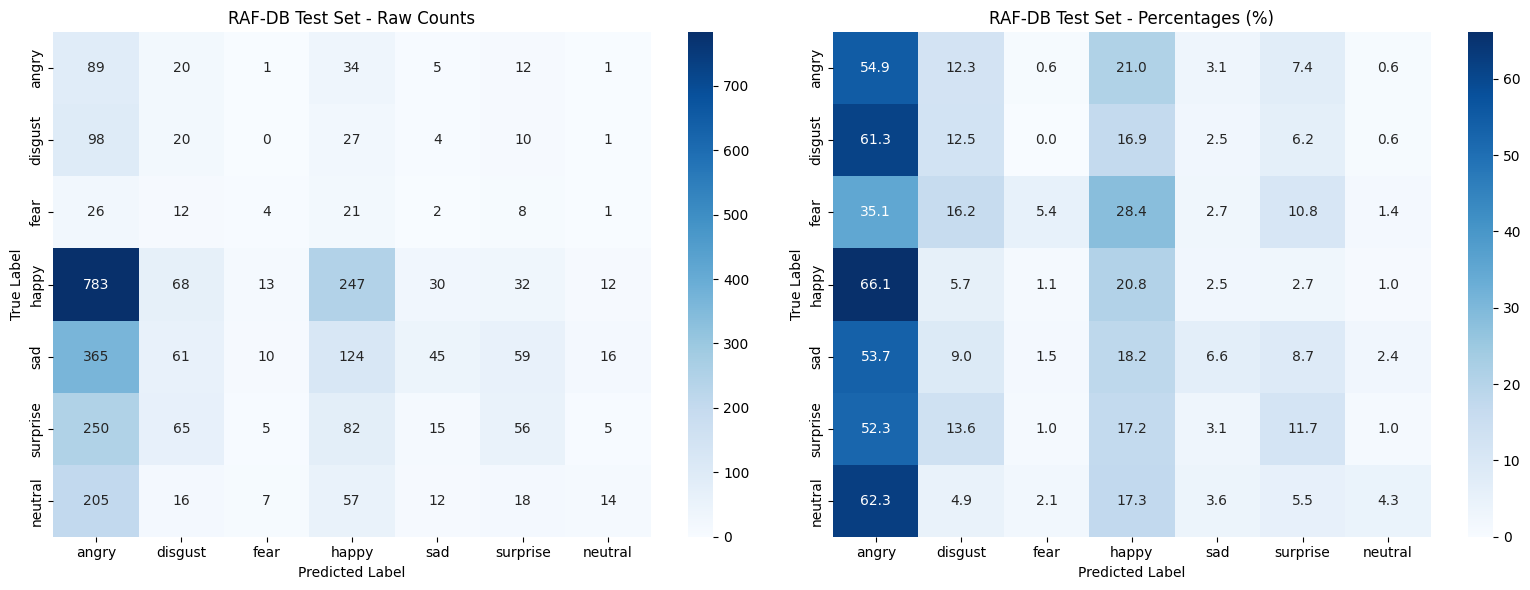


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.0490    0.5494    0.0900       162
     disgust     0.0763    0.1250    0.0948       160
        fear     0.1000    0.0541    0.0702        74
       happy     0.4172    0.2084    0.2780      1185
         sad     0.3982    0.0662    0.1135       680
    surprise     0.2872    0.1172    0.1664       478
     neutral     0.2800    0.0426    0.0739       329

    accuracy                         0.1548      3068
   macro avg     0.2297    0.1661    0.1267      3068
weighted avg     0.3332    0.1548    0.1778      3068


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  54.94%
disgust     :  12.50%
fear        :   5.41%
happy       :  20.84%
sad         :   6.62%
surprise    :  11.72%
neutral     :   4.26%

------------------------------------------------------------
Summary Metrics

In [22]:
print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics_with_uar_war(fer_labels, fer_preds, emotions, 'FER2013')

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics_with_uar_war(raf_labels, raf_preds, emotions, 'RAF-DB')

### 4.2.4 Summary Comparison Table

In [23]:
print("\n" + "="*60)
print("Cross-Dataset Performance Summary")
print("="*60)

fer_uar, fer_war, _ = calculate_uar_war(fer_labels, fer_preds, emotions)
raf_uar, raf_war, _ = calculate_uar_war(raf_labels, raf_preds, emotions)

fer_acc = (fer_preds == fer_labels).sum() / len(fer_labels) * 100
raf_acc = (raf_preds == raf_labels).sum() / len(raf_labels) * 100

print(f"\n{'Metric':<30} {'FER2013':>12} {'RAF-DB':>12}")
print("-"*60)
print(f"{'Overall Accuracy':<30} {fer_acc:>11.2f}% {raf_acc:>11.2f}%")
print(f"{'WAR (Weighted Avg Recall)':<30} {fer_war:>11.2f}% {raf_war:>11.2f}%")
print(f"{'UAR (Unweighted Avg Recall)':<30} {fer_uar:>11.2f}% {raf_uar:>11.2f}%")
print("-"*60)


Cross-Dataset Performance Summary

Metric                              FER2013       RAF-DB
------------------------------------------------------------
Overall Accuracy                     32.61%       15.48%
WAR (Weighted Avg Recall)            32.61%       15.48%
UAR (Unweighted Avg Recall)          33.62%       16.61%
------------------------------------------------------------


### 4.2.5 Minority Class Performance with UAR and WAR

In [24]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

print(f"\n{'Class':<12} {'Dataset':<10} {'Recall':<10} {'Samples':<10}")
print("-"*60)

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    # FER2013
    fer_mask = fer_labels == cls_idx
    if fer_mask.sum() > 0:
        fer_recall = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'FER2013':<10} {fer_recall:>8.2f}% {fer_mask.sum():>9}")
    
    # RAF-DB
    raf_mask = raf_labels == cls_idx
    if raf_mask.sum() > 0:
        raf_recall = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'RAF-DB':<10} {raf_recall:>8.2f}% {raf_mask.sum():>9}")
    
    print()


Minority Class Performance (Disgust & Fear)

Class        Dataset    Recall     Samples   
------------------------------------------------------------
Disgust      FER2013       51.35%       111
Disgust      RAF-DB        12.50%       160

Fear         FER2013        8.40%      1024
Fear         RAF-DB         5.41%        74



# 5. Stage 2: Feature Extraction and Synthesis

## 5.1 Extract Features

In [32]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting Features"):
            images = images.to(device)

            x = model.patch_embed(images)

            for block in model.layer1:
                x = block(x)
            x = model.merge1(x)

            for block in model.layer2:
                x = block(x)
            x = model.merge2(x)

            for block in model.layer3:
                x = block(x)
            x = model.merge3(x)
            
            for block in model.layer4:
                x = block(x)

            x = model.norm(x)
            x = x.transpose(1, 2)
            x = model.avgpool1d(x)
            x = torch.flatten(x, 1)

            all_features.append(x.cpu().numpy())
            all_labels.append(labels.numpy())

        features = np.vstack(all_features)
        labels = np.concatenate(all_labels)

        return features, labels

## 5.2 Apply SMOTE on extracted deep features

In [33]:
def apply_smote(features, labels, random_state=42):
    print("Original class distribution:")
    print(Counter(labels))
    
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    balanced_features, balanced_labels = smote.fit_resample(features, labels)

    print("Balanced class distribution:")
    print(Counter(balanced_labels))

    return balanced_features, balanced_labels

In [34]:
features, labels = extract_features(model, train_loader, device)
balanced_features, balanced_labels = apply_smote(features, labels)

Extracting Features: 100%|███████████████████████████████████████████████████████████| 898/898 [01:37<00:00,  9.20it/s]


Original class distribution:
Counter({np.int64(3): 7215, np.int64(4): 4965, np.int64(5): 4830, np.int64(2): 4097, np.int64(0): 3995, np.int64(6): 3171, np.int64(1): 436})
Balanced class distribution:
Counter({np.int64(4): 7215, np.int64(6): 7215, np.int64(0): 7215, np.int64(3): 7215, np.int64(5): 7215, np.int64(2): 7215, np.int64(1): 7215})


# 6. Stage 3: Retraining the MLP Head

In [45]:
def retrain_mlp_head(model, features, labels, device, epochs=20, batch_size=128, lr=1e-3, weight_decay=1e-3):
    # Freeze all params in Swin-X backbone
    for param in model.patch_embed.parameters():
        param.requires_grad = False
    for stage in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in stage:
            for param in block.parameters():
                param.requires_grad = False

    for merge in [model.merge1, model.merge2, model.merge3]:
        for param in merge.parameters():
            param.requires_grad = False

    for param in model.head.parameters():
        param.requires_grad = False

    features_tensor = torch.FloatTensor(features)
    labels_tensor = torch.LongTensor(features)
    dataset = torch.utils.data.TensorDataset(features_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_features, batch_labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            optimiser.zero_grad()

            outputs = model.head(batch_features)

            loss = criterion(outputs, batch_labels)

            loss.backward()
            optimiser.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += batch_labels.size(0)
            correct += predicted.eq(batch_labels).sum().item()

        epoch_loss = running_loss / len(data_loader)
        epoch_acc = correct * 100. / total

        print(f"Epoch {epoch+1}/{epochs}   Loss: {epoch_loss}   Accuracy: {epoch_acc}")

    return model

In [47]:
model = retrain_mlp_head(model, balanced_features, balanced_labels, device)

torch.save(model.state_dict(), 'swin_xception_final.pth')

Epoch 1/20:   0%|                                                                              | 0/395 [00:00<?, ?it/s]


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# 7. Evaluation Metrics and Visualisation on Balanced set

## 7.1 Validate Loss and Accuracy on Test sets

In [ ]:
fer_loss, fer_acc = validate(model, test_fer_loader, criterion, device)
raf_loss, raf_acc = validate(model, test_raf_loader, criterion, device)

print(f"FER2013 | new loss: {fer_loss:.4f} | new accuracy: {fer_acc:.2f}")
print(f"RAF-DB | new loss: {fer_loss:.4f} | new accuracy: {fer_acc:.2f}")

# QUICK SAVE AND LOAD
Use this cell if there are no outstanding changes to your model after the generation of a training loop's last state dict, and want to test later stages (feature extraction, smote and retraining, etc.)

In [48]:
PATH = "spare_checkpoints/latest.pth"
os.makedirs("model_checkpoints", exist_ok=True)

epochs = 50

model = SwinXception(num_classes=7).to(device)
optimiser = AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
scheduler = CosineAnnealingLR(optimiser, T_max=epochs)

start_epoch = 0

if os.path.exists(PATH):
    checkpoint = torch.load(PATH, map_location=device)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint found! Starting from epoch {start_epoch}...")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimiser_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
else:
    print("No model checkpoints found. Starting from epoch 1...")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# Experimentation 3 - Outcomes: